In [4]:
!pip install pandas numpy scikit-learn matplotlib seaborn umap-learn

In [5]:
import pandas as pd
import numpy as np
import os
import re
import logging
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm


# Setup basic logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
if not logger.handlers:
    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)

## 1. Load Data and Embeddings

**Note:** Please ensure `sentencePair.txt`, `sentencePair_neg.txt`, and the `artifacts` directory (containing `combined_embeddings.npy` and `combined_ids.csv`) are in the same directory as this notebook.

In [6]:
class Config:
    POS_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    EMB_PATH = "/kaggle/input/lrec-tcs-attack-vs-support-finetuned-embeddings/inlbert_finetuned_embeddings.npy"
    IDS_PATH = "/kaggle/input/lrec-tcs-attack-vs-support-finetuned-embeddings/Inlbert_finetuned_ids.csv"
    # EMB_PATH = "/kaggle/input/lrec-tcs-support-vs-attack-embeddings/LegalBERT_cls_embeddings.npy"
    # IDS_PATH = "/kaggle/input/lrec-tcs-support-vs-attack-embeddings/LegalBERT_cls_ids.csv"

def parse_lrec_line(line: str):
    """
    Parses a single line from the .txt file.
    MUST be identical to the function in the LBERT notebook.
    """
    parts = line.strip().split("\t")
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2: return None
    try:
        # Use 'sentpair_id' to match the LBERT notebook's internal name
        sentpair_id = int(parts[0]) 
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except (ValueError, IndexError): return None
    return {"sentpair_id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

def load_full_data(config: Config):
    """
    Loads, cleans, splits, and concatenates data in the *exact* same
    order as the LBERT notebook's `load_and_split_data` followed by
    the creation of the 'combined' PairDataset.
    This ensures 1:1 row alignment with 'combined_embeddings.npy'.
    """
    logging.info("Loading full dataset with LBERT-compatible split/concat logic...")
    rows = []
    
    # --- 1. Load from both files (identical to load_and_split_data) ---
    for fp in [config.POS_DATA_FILE, config.NEG_DATA_FILE]:
        if not os.path.exists(fp):
            logging.error(f"Data file not found at '{fp}'. Please add it.")
            return None
        with open(fp, "r", encoding="utf-8") as f:
            for line in f:
                if parsed := parse_lrec_line(line):
                    # --- Use 'sentpair_id' consistently ---
                    if 'id' in parsed: # If parse_lrec_line uses 'id'
                        parsed['sentpair_id'] = parsed.pop('id')
                    rows.append(parsed)
                    
    df = pd.DataFrame(rows)
    
    # --- 2. Clean data (identical to load_and_split_data) ---
    LABEL_MAP = {"SUPPORT": 0, "ATTACK": 1, "NO_REL": 2} # Local definition
    df["label_id"] = df["label"].map(LABEL_MAP)
    # --- Use 'sentpair_id' for dropna subset ---
    df = df.dropna(subset=["sentpair_id", "sent1", "sent2", "label_id"])
    
    # --- 3. Perform the Train/Test Split (identical to load_and_split_data) ---
    # config variables
    RANDOM_STATE = 42
    TEST_SET_SIZE = 0.2
    
    train_df, test_df = train_test_split(df, test_size=TEST_SET_SIZE,
                                         random_state=RANDOM_STATE,
                                         stratify=df["label_id"])
    
    # Reset index *after* split, just like before
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    
    # --- 4. Concatenate Train and Test (identical to 'combined' PairDataset creation) ---
    df_combined_ordered = pd.concat([train_df, test_df]).reset_index(drop=True)
    
    # Ensure label_id is integer type
    df_combined_ordered['label_id'] = df_combined_ordered['label_id'].astype(int)
    
    logging.info(f"Full dataset loaded and processed like LBERT notebook. Total samples: {len(df_combined_ordered)}")
    
    # This df is now row-aligned with the embeddings
    return df_combined_ordered

# --- Load all components ---
cfg = Config()
df_aligned = load_full_data(cfg) 

if df_aligned is not None:
    embeddings = np.load(cfg.EMB_PATH)
    ids_df = pd.read_csv(cfg.IDS_PATH) # Load for verification
    
    logger.info(f"Loaded DataFrame shape: {df_aligned.shape}")
    logger.info(f"Loaded embeddings shape: {embeddings.shape}")
    logger.info(f"Loaded IDs shape: {ids_df.shape}")
    
    # --- Alignment Check ---
    if len(df_aligned) == len(embeddings) and len(df_aligned) == len(ids_df):
        logger.info("SUCCESS: DataFrame, embeddings, and IDs have matching lengths.")
        # Final check: compare the IDs column-wise
        mismatches = (df_aligned['sentpair_id'] != ids_df['id']).sum()
        if mismatches == 0:
            logger.info("✅ SUCCESS: 'sentpair_id' column matches 'id' column from CSV.")
        else:
            logger.error(f"--- CRITICAL ERROR ---")
            logger.error(f"ID mismatch detected: {mismatches} rows have different IDs.")
            logger.error("Even though lengths match, the row order is incorrect.")
            logger.error("Check data parsing/cleaning/splitting logic VERY carefully.")
            df_aligned = None # Stop execution
    else:
        logger.error("--- CRITICAL ERROR ---")
        logger.error("Shape mismatch between loaded data and embeddings.")
        logger.error(f"DataFrame rows: {len(df_aligned)}")
        logger.error(f"Embedding rows: {len(embeddings)}")
        logger.error(f"ID CSV rows: {len(ids_df)}")
        logger.error("This means the data loading logic is out of sync with the embedding generation notebook.")
        df_aligned = None # Stop subsequent cells
else:
    logger.error("Could not load data. Halting notebook execution.")


2025-10-29 09:16:37,279 - INFO - Loaded DataFrame shape: (40506, 5)
2025-10-29 09:16:37,280 - INFO - Loaded embeddings shape: (40506, 768)
2025-10-29 09:16:37,281 - INFO - Loaded IDs shape: (40506, 1)
2025-10-29 09:16:37,282 - INFO - SUCCESS: DataFrame, embeddings, and IDs have matching lengths.
2025-10-29 09:16:37,284 - INFO - ✅ SUCCESS: 'sentpair_id' column matches 'id' column from CSV.


## 2. Elbow Method for Optimal K (Knee Plot)

Calculate the Sum of Squared Distances (Inertia) for different `k` values. The 'elbow' or 'knee' suggests a good trade-off.

2025-10-29 09:16:37,293 - INFO - Calculating SSE for k in range(1, 11)...


  0%|          | 0/10 [00:00<?, ?it/s]

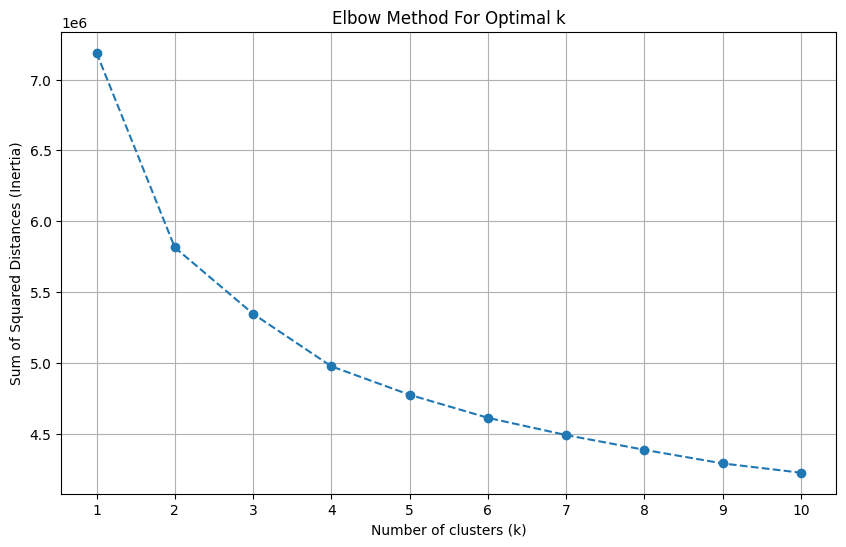

2025-10-29 09:18:31,013 - INFO - Examine the plot. The 'elbow' point indicates a potential optimal k.
2025-10-29 09:18:31,014 - INFO - Consider k=2 (Arg vs Non-Arg) or k=3 (Attack/Support/NoRel).


In [7]:
if embeddings is not None:
    sse = {}
    k_range = range(1, 11) # Test k from 1 to 10
    logger.info(f"Calculating SSE for k in {k_range}...")

    for k_val in tqdm(k_range):
        kmeans_elbow = KMeans(n_clusters=k_val, random_state=42, n_init=10)
        kmeans_elbow.fit(embeddings)
        sse[k_val] = kmeans_elbow.inertia_ # SSE

    # Plotting the Elbow Curve
    plt.figure(figsize=(10, 6))
    plt.plot(list(sse.keys()), list(sse.values()), marker='o', linestyle='--')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Sum of Squared Distances (Inertia)")
    plt.title("Elbow Method For Optimal k")
    plt.xticks(list(sse.keys()))
    plt.grid(True)
    plt.show()

    logger.info("Examine the plot. The 'elbow' point indicates a potential optimal k.")
    logger.info("Consider k=2 (Arg vs Non-Arg) or k=3 (Attack/Support/NoRel).")
else:
     logger.error("Cannot run Elbow method because embeddings are not loaded.")

## 3. K-Means Clustering

Choose `n_clusters` based on the elbow plot or your hypothesis.

In [8]:
if df_aligned is not None and embeddings is not None:
    # --- SET YOUR DESIRED NUMBER OF CLUSTERS HERE ---
    n_clusters = 2 # Defaulting to 2, ADJUST AS NEEDED based on Elbow plot
    # -------------------------------------------------

    logger.info(f"Running K-Means with n_clusters={n_clusters}...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Add cluster labels to the aligned DataFrame
    df_aligned['cluster'] = cluster_labels

    # Calculate Silhouette Score (only if more than 1 cluster)
    if n_clusters > 1:
        try:
            silhouette_avg = silhouette_score(embeddings, cluster_labels)
            logger.info(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")
        except Exception as e:
            logger.warning(f"Could not calculate silhouette score: {e}")
    else:
        logger.info("Silhouette score requires n_clusters > 1.")

else:
    logger.error("Cannot run K-Means because data or embeddings are not loaded.")

2025-10-29 09:18:31,024 - INFO - Running K-Means with n_clusters=2...
2025-10-29 09:19:33,411 - INFO - For n_clusters = 2, the average silhouette_score is : 0.1749


## 4. Analysis: Cluster Composition

2025-10-29 09:19:33,419 - INFO - --- Cluster Composition Analysis ---


\nCross-tabulation (Original Label vs. Predicted Cluster):
cluster      0     1
label               
ATTACK     854  8906
NO_REL   16260  3740
SUPPORT   1025  9721


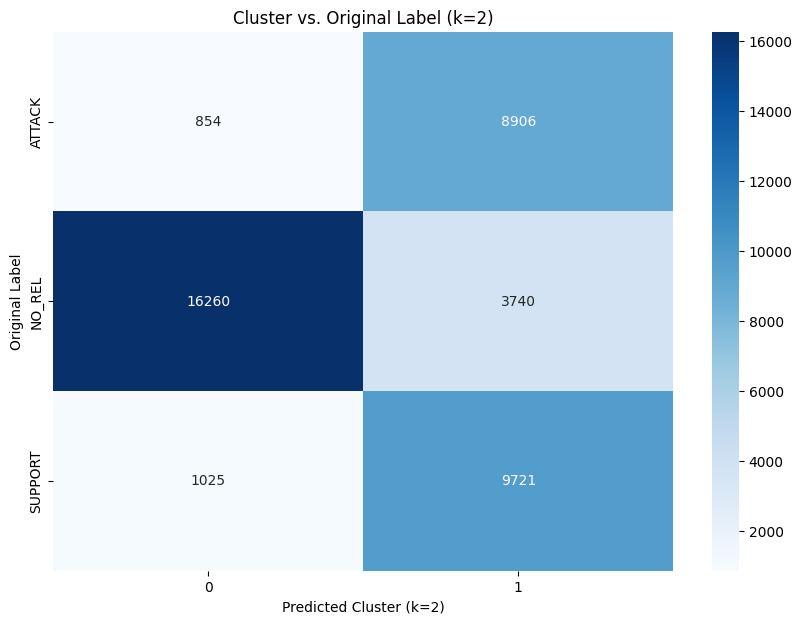

In [9]:
if df_aligned is not None:
    if 'cluster' in df_aligned.columns:
        logger.info("--- Cluster Composition Analysis ---")

        crosstab = pd.crosstab(df_aligned['label'], df_aligned['cluster'])
        print("\\nCross-tabulation (Original Label vs. Predicted Cluster):")
        print(crosstab)

        plt.figure(figsize=(10, 7)) # Adjusted size slightly
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
        # Use the n_clusters variable in the title and xlabel
        plt.title(f"Cluster vs. Original Label (k={n_clusters})")
        plt.xlabel(f"Predicted Cluster (k={n_clusters})")
        plt.ylabel("Original Label")
        plt.show()
    else:
        logger.error("K-Means clustering step did not complete. Cannot show composition.")
else:
    logger.error("Cannot analyze composition because data is not loaded.")


# For n = 2, Precision = 18627/22367 = 0.833 (Argumentative vs Non Argumentative)
# Recall = 18627/20506 = 0.908
# F1 = 0.869
# Accuracy = 34887/40506 = 0.861

## 5. Analysis: Sample Inspection

checking few points from each cluster

In [10]:
if df_aligned is not None and 'cluster' in df_aligned.columns:
    pd.set_option('display.max_colwidth', 200)

    # Display samples for each cluster found
    unique_clusters = sorted(df_aligned['cluster'].unique())
    num_clusters_found = len(unique_clusters) # Get actual number found
    logger.info(f"Found {num_clusters_found} unique cluster labels: {unique_clusters}")


    for clus_id in unique_clusters:
        print("\\n" + "="*50)
        logger.info(f"Sample Points from Cluster {clus_id}")
        print("="*50)
        cluster_data = df_aligned[df_aligned['cluster'] == clus_id]
        sample_size = min(5, len(cluster_data)) # Sample up to 5

        if sample_size > 0:
           print(cluster_data[['sent1', 'sent2', 'label']].sample(sample_size, random_state=42))
        else:
           print(f"Cluster {clus_id} has no samples.")
else:
    logger.error("Cannot inspect samples because data or cluster labels are missing.")

2025-10-29 09:19:33,687 - INFO - Found 2 unique cluster labels: [0, 1]
2025-10-29 09:19:33,689 - INFO - Sample Points from Cluster 0
2025-10-29 09:19:33,702 - INFO - Sample Points from Cluster 1


\n==================================================
                                                                                                                                                                                                         sent1  \
21696  He alternatively contended that , in any case , the Will could not be treated as a valid legal document under which the right of management of schedule C kattalai properties could be entrusted to ...   
32150                                                       In addition , the appellant submits that the Scheme framed by BIFR also did not lay down any ceiling on the quantum of deferral of the sales tax .   
25155                                                                                                                                                                   ( b ) ................................   
23037  It is now well settled that even under the Sales Tax laws , the charge in respect of a sale or purch

## 6. Visualization with UMAP

visualizing the clusters to see the separation.

2025-10-29 09:19:33,727 - INFO - Reducing dimensions with UMAP for visualization...
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
2025-10-29 09:20:44,505 - INFO - Plotting by K-Means Cluster (k=2)...


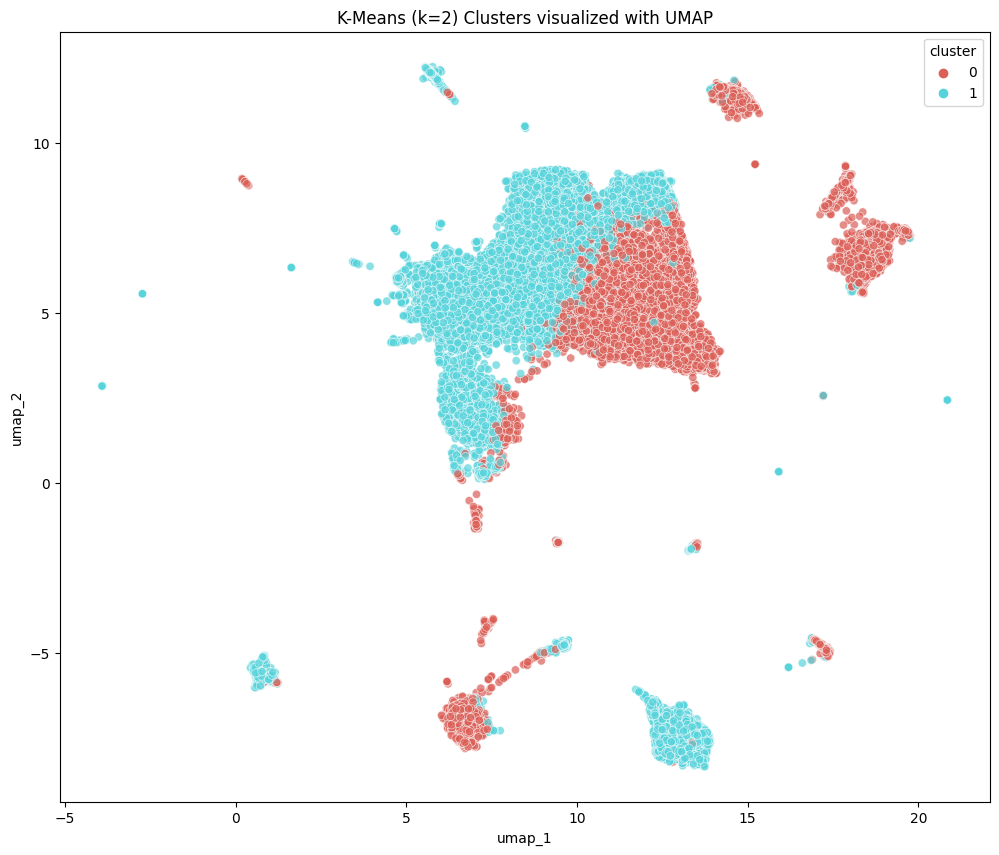

2025-10-29 09:20:46,555 - INFO - Plotting by Original Label...


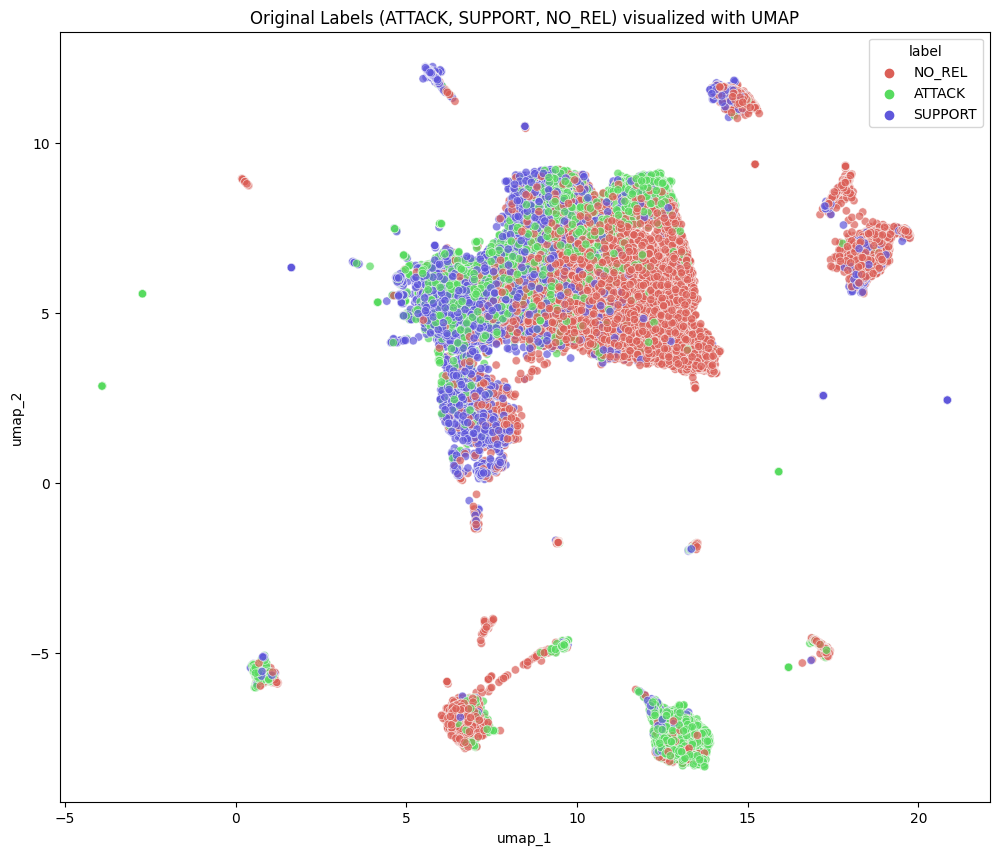

2025-10-29 09:20:47,987 - INFO - Plotting UMAP with Color=Cluster (k=2), Shape=Original Label...


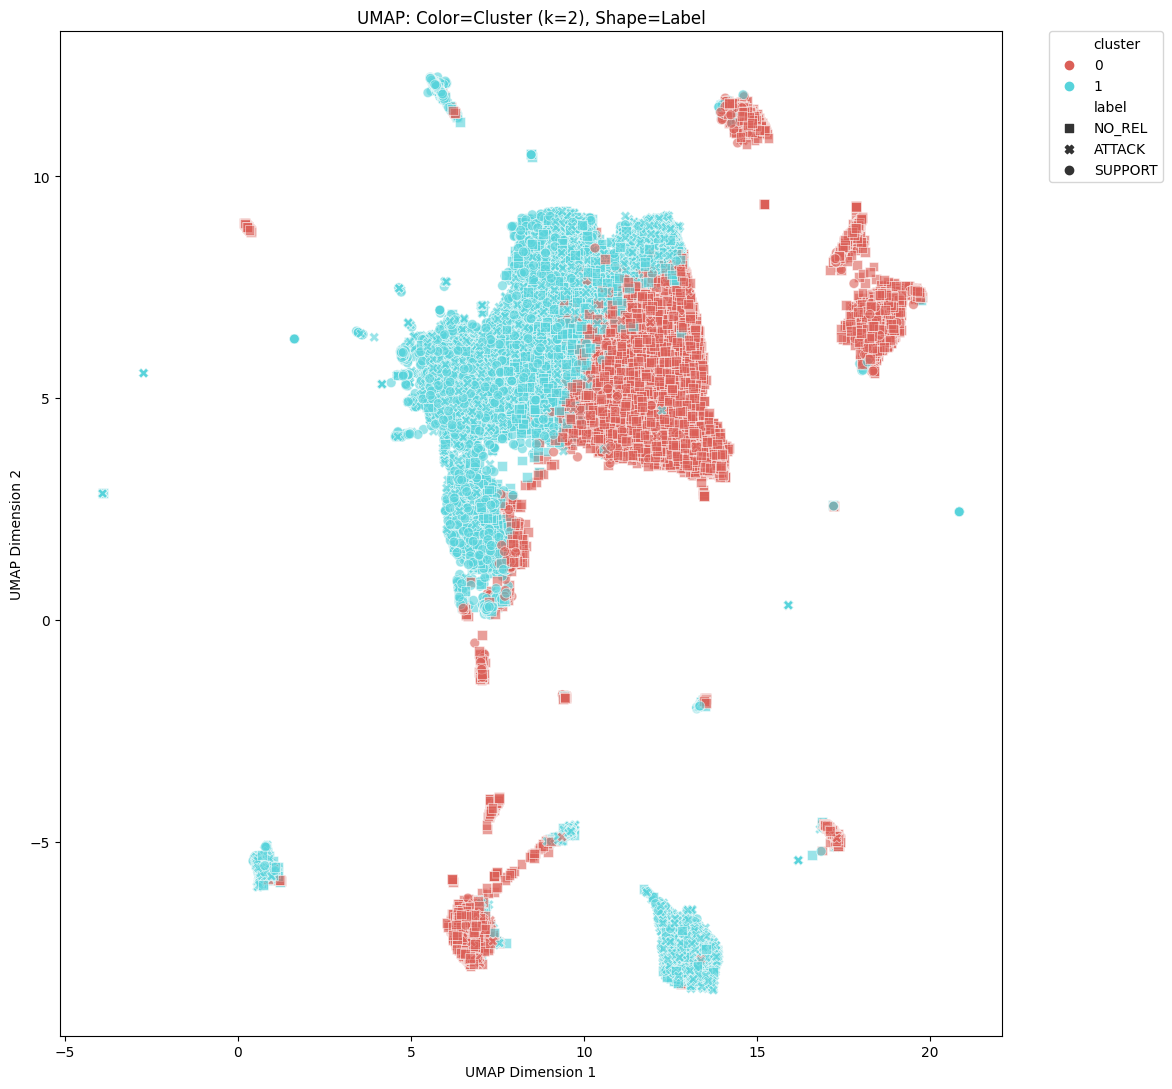

In [11]:
if df_aligned is not None and embeddings is not None and 'cluster' in df_aligned.columns:
    logger.info("Reducing dimensions with UMAP for visualization...")

    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    df_aligned['umap_1'] = embeddings_2d[:, 0]
    df_aligned['umap_2'] = embeddings_2d[:, 1]

    # --- Plot 1: Color by K-Means Cluster ---
    logger.info(f"Plotting by K-Means Cluster (k={n_clusters})...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',
        # Use a palette suitable for n_clusters
        palette=sns.color_palette('hls', n_clusters),
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title(f'K-Means (k={n_clusters}) Clusters visualized with UMAP')
    plt.show()

    # --- Plot 2: Color by Original Label ---
    logger.info("Plotting by Original Label...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='label',
        palette=sns.color_palette('hls', 3), # 3 original labels
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title('Original Labels (ATTACK, SUPPORT, NO_REL) visualized with UMAP')
    plt.show()

    # --- Plot 3 (NEW): Color by Cluster, Shape by Label ---
    logger.info(f"Plotting UMAP with Color=Cluster (k={n_clusters}), Shape=Original Label...")
    plt.figure(figsize=(14, 11))

    scatter = sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',      # Color by K-Means cluster
        style='label',      # Shape by original label
        palette=sns.color_palette('hls', n_clusters), # Use n_clusters colors
        markers={'ATTACK': 'X', 'SUPPORT': 'o', 'NO_REL': 's'}, # Assign markers
        data=df_aligned,
        alpha=0.6,
        s=50 # Point size
    )

    plt.title(f'UMAP: Color=Cluster (k={n_clusters}), Shape=Label')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    logger.error("Cannot create UMAP plots because data, embeddings, or cluster labels are missing.")

## Performing the KMeans for 3 Clusters

In [12]:
if df_aligned is not None and embeddings is not None:
    # --- SET YOUR DESIRED NUMBER OF CLUSTERS HERE ---
    n_clusters = 3
    # -------------------------------------------------

    logger.info(f"Running K-Means with n_clusters={n_clusters}...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Add cluster labels to the aligned DataFrame
    df_aligned['cluster'] = cluster_labels

    # Calculate Silhouette Score (only if more than 1 cluster)
    if n_clusters > 1:
        try:
            silhouette_avg = silhouette_score(embeddings, cluster_labels)
            logger.info(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")
        except Exception as e:
            logger.warning(f"Could not calculate silhouette score: {e}")
    else:
        logger.info("Silhouette score requires n_clusters > 1.")

else:
    logger.error("Cannot run K-Means because data or embeddings are not loaded.")

2025-10-29 09:20:49,266 - INFO - Running K-Means with n_clusters=3...
2025-10-29 09:21:58,166 - INFO - For n_clusters = 3, the average silhouette_score is : 0.1494


2025-10-29 09:21:58,175 - INFO - --- Cluster Composition Analysis ---


\nCross-tabulation (Original Label vs. Predicted Cluster):
cluster     0      1     2
label                     
ATTACK   4627    754  4379
NO_REL   3113  15811  1076
SUPPORT  9531    836   379


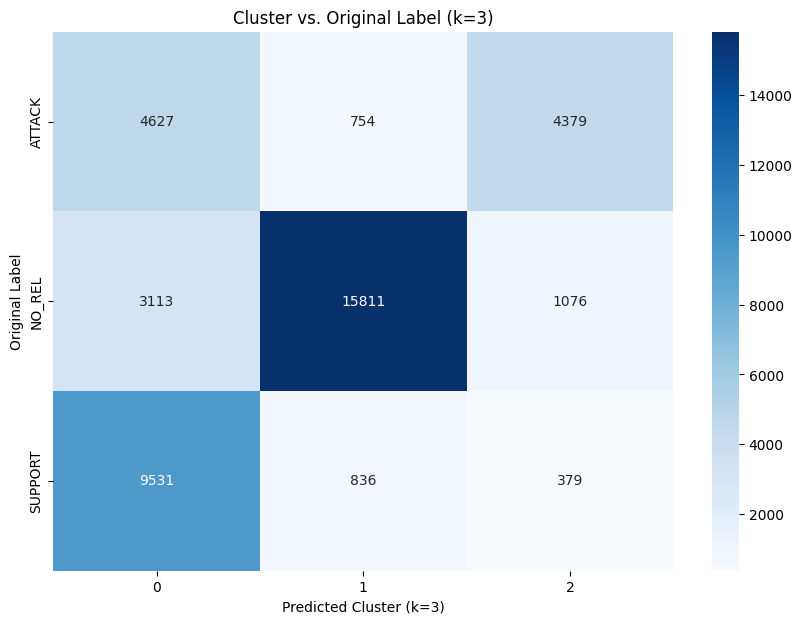

In [13]:
if df_aligned is not None:
    if 'cluster' in df_aligned.columns:
        logger.info("--- Cluster Composition Analysis ---")

        crosstab = pd.crosstab(df_aligned['label'], df_aligned['cluster'])
        print("\\nCross-tabulation (Original Label vs. Predicted Cluster):")
        print(crosstab)

        plt.figure(figsize=(10, 7)) # Adjusted size slightly
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
        # Use the n_clusters variable in the title and xlabel
        plt.title(f"Cluster vs. Original Label (k={n_clusters})")
        plt.xlabel(f"Predicted Cluster (k={n_clusters})")
        plt.ylabel("Original Label")
        plt.show()
    else:
        logger.error("K-Means clustering step did not complete. Cannot show composition.")
else:
    logger.error("Cannot analyze composition because data is not loaded.")




In [14]:
if df_aligned is not None and 'cluster' in df_aligned.columns:
    pd.set_option('display.max_colwidth', 200)

    # Display samples for each cluster found
    unique_clusters = sorted(df_aligned['cluster'].unique())
    num_clusters_found = len(unique_clusters) # Get actual number found
    logger.info(f"Found {num_clusters_found} unique cluster labels: {unique_clusters}")


    for clus_id in unique_clusters:
        print("\\n" + "="*50)
        logger.info(f"Sample Points from Cluster {clus_id}")
        print("="*50)
        cluster_data = df_aligned[df_aligned['cluster'] == clus_id]
        sample_size = min(5, len(cluster_data)) # Sample up to 5

        if sample_size > 0:
           print(cluster_data[['sent1', 'sent2', 'label']].sample(sample_size, random_state=42))
        else:
           print(f"Cluster {clus_id} has no samples.")
else:
    logger.error("Cannot inspect samples because data or cluster labels are missing.")

2025-10-29 09:21:58,435 - INFO - Found 3 unique cluster labels: [0, 1, 2]
2025-10-29 09:21:58,436 - INFO - Sample Points from Cluster 0
2025-10-29 09:21:58,450 - INFO - Sample Points from Cluster 1
2025-10-29 09:21:58,462 - INFO - Sample Points from Cluster 2


\n==================================================
                                                                                                                                                                                                         sent1  \
6270   Whether the terms in which the declaration has been framed in Section 2 of the Industries ( Development and Regulation ) Act-a declaration not expressly limiting control of the specific indus- 363...   
29894  The learned counsel for the appellants submitted that only such decision of the Commission determining delimitation of Constituencies after following the mandatory procedure under Section 9 ( 2 ) ...   
36161                                                                                                                                                                                          Leave granted .   
40461  If it were so , then it has to be said that in so far as the Legislature has not thought it fit to r

2025-10-29 09:21:58,481 - INFO - Reducing dimensions with UMAP for visualization...
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
2025-10-29 09:22:44,046 - INFO - Plotting by K-Means Cluster (k=3)...


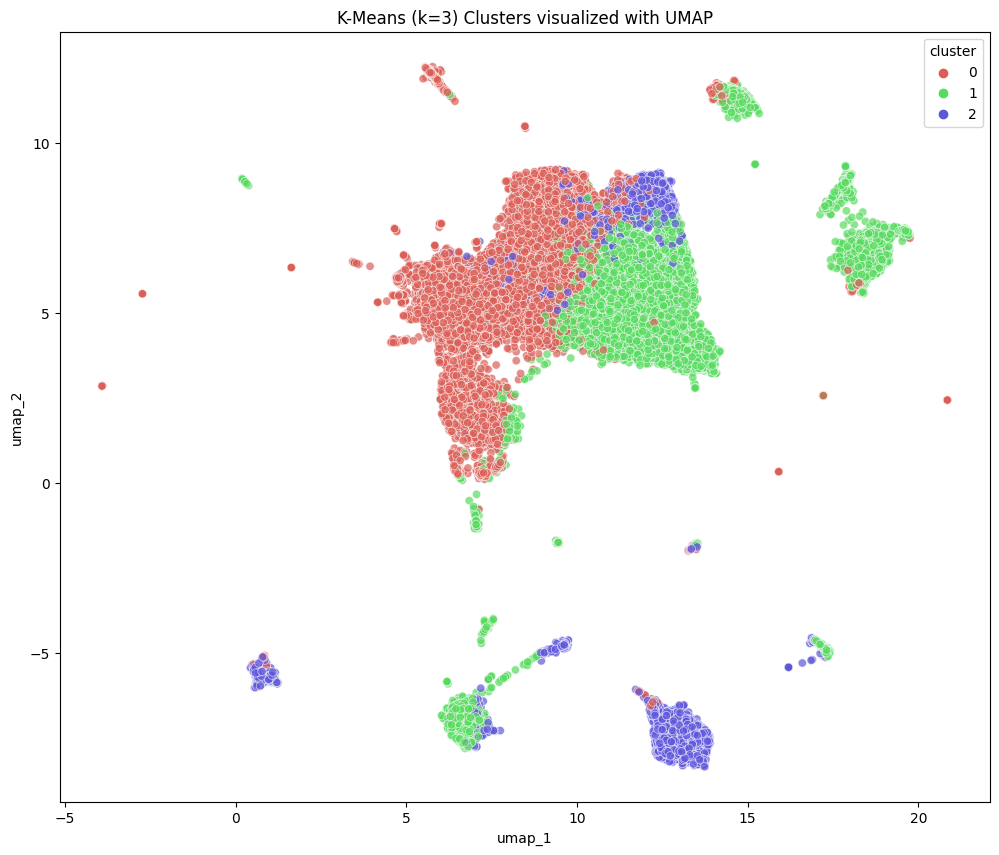

2025-10-29 09:22:45,499 - INFO - Plotting by Original Label...


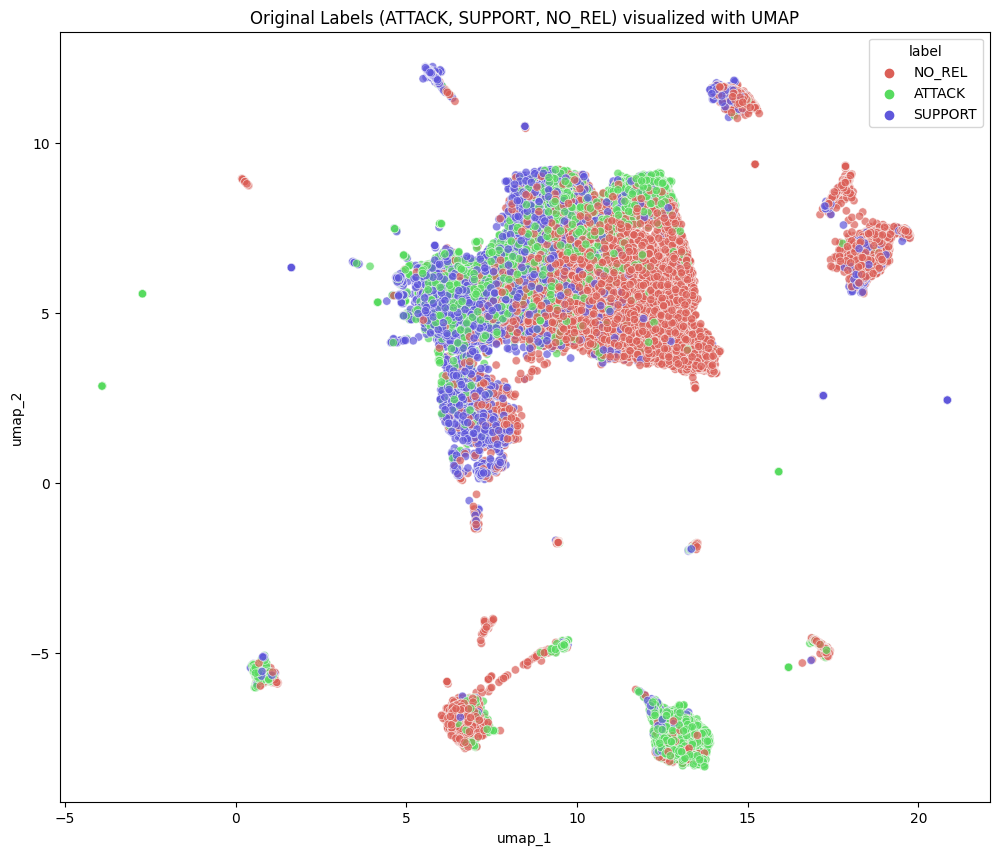

2025-10-29 09:22:46,955 - INFO - Plotting UMAP with Color=Cluster (k=3), Shape=Original Label...


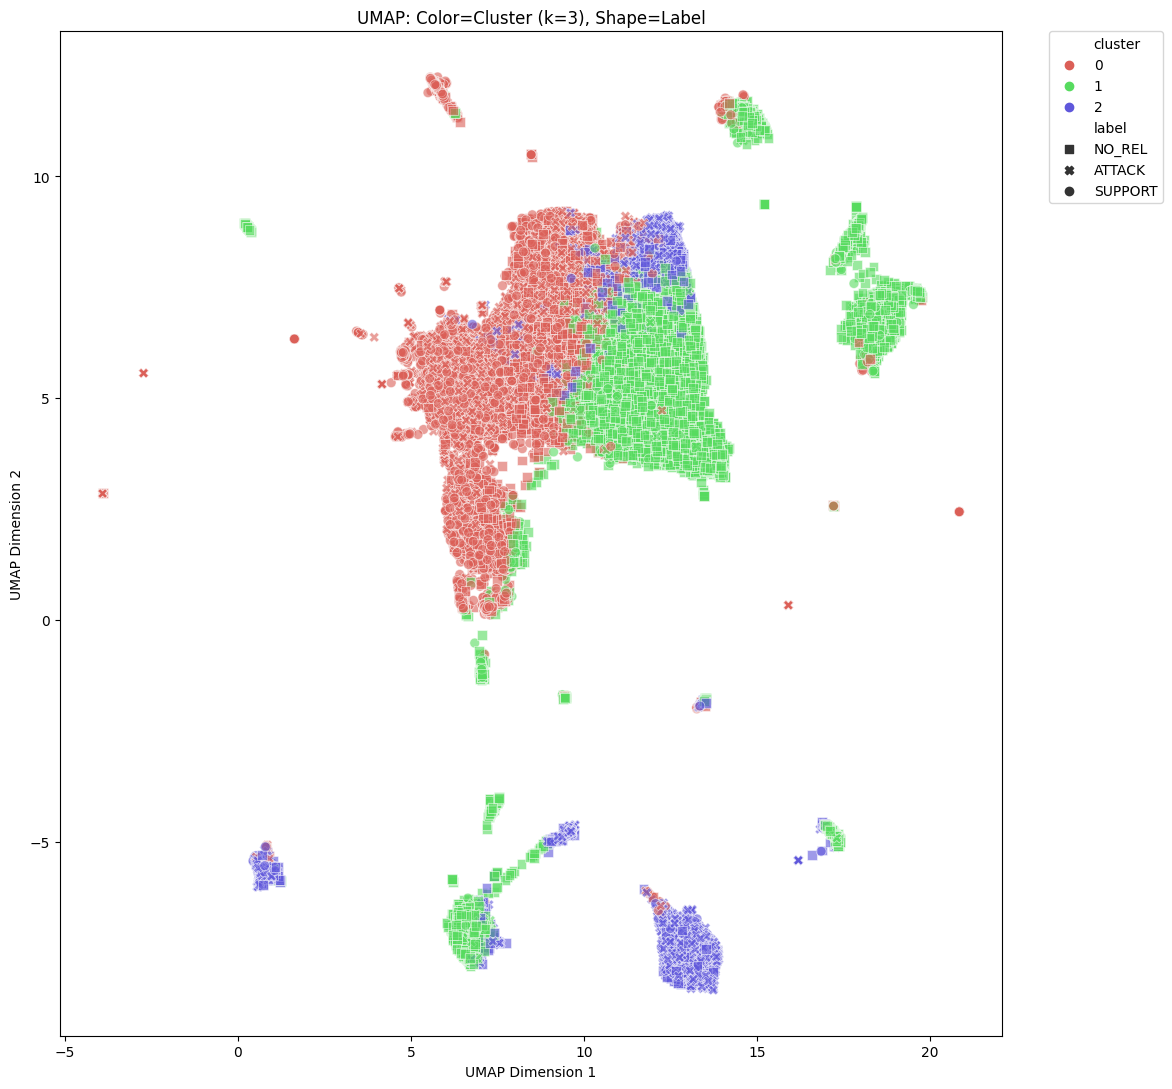

In [15]:
if df_aligned is not None and embeddings is not None and 'cluster' in df_aligned.columns:
    logger.info("Reducing dimensions with UMAP for visualization...")

    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    df_aligned['umap_1'] = embeddings_2d[:, 0]
    df_aligned['umap_2'] = embeddings_2d[:, 1]

    # --- Plot 1: Color by K-Means Cluster ---
    logger.info(f"Plotting by K-Means Cluster (k={n_clusters})...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',
        # Use a palette suitable for n_clusters
        palette=sns.color_palette('hls', n_clusters),
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title(f'K-Means (k={n_clusters}) Clusters visualized with UMAP')
    plt.show()

    # --- Plot 2: Color by Original Label ---
    logger.info("Plotting by Original Label...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='label',
        palette=sns.color_palette('hls', 3), # 3 original labels
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title('Original Labels (ATTACK, SUPPORT, NO_REL) visualized with UMAP')
    plt.show()

    # --- Plot 3 (NEW): Color by Cluster, Shape by Label ---
    logger.info(f"Plotting UMAP with Color=Cluster (k={n_clusters}), Shape=Original Label...")
    plt.figure(figsize=(14, 11))

    scatter = sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',      # Color by K-Means cluster
        style='label',      # Shape by original label
        palette=sns.color_palette('hls', n_clusters), # Use n_clusters colors
        markers={'ATTACK': 'X', 'SUPPORT': 'o', 'NO_REL': 's'}, # Assign markers
        data=df_aligned,
        alpha=0.6,
        s=50 # Point size
    )

    plt.title(f'UMAP: Color=Cluster (k={n_clusters}), Shape=Label')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    logger.error("Cannot create UMAP plots because data, embeddings, or cluster labels are missing.")

## Performing the KMeans for Optimal Clusters

In [16]:
if df_aligned is not None and embeddings is not None:
    
    n_clusters = 4
    # -------------------------------------------------

    logger.info(f"Running K-Means with n_clusters={n_clusters}...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Add cluster labels to the aligned DataFrame
    df_aligned['cluster'] = cluster_labels

    # Calculate Silhouette Score (only if more than 1 cluster)
    if n_clusters > 1:
        try:
            silhouette_avg = silhouette_score(embeddings, cluster_labels)
            logger.info(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")
        except Exception as e:
            logger.warning(f"Could not calculate silhouette score: {e}")
    else:
        logger.info("Silhouette score requires n_clusters > 1.")

else:
    logger.error("Cannot run K-Means because data or embeddings are not loaded.")

2025-10-29 09:22:48,246 - INFO - Running K-Means with n_clusters=4...
2025-10-29 09:23:53,512 - INFO - For n_clusters = 4, the average silhouette_score is : 0.1356


2025-10-29 09:23:53,523 - INFO - --- Cluster Composition Analysis ---


\nCross-tabulation (Original Label vs. Predicted Cluster):
cluster      0     1     2     3
label                           
ATTACK    1039    38  3984  4699
NO_REL   12708  4005   604  2683
SUPPORT    338   996   347  9065


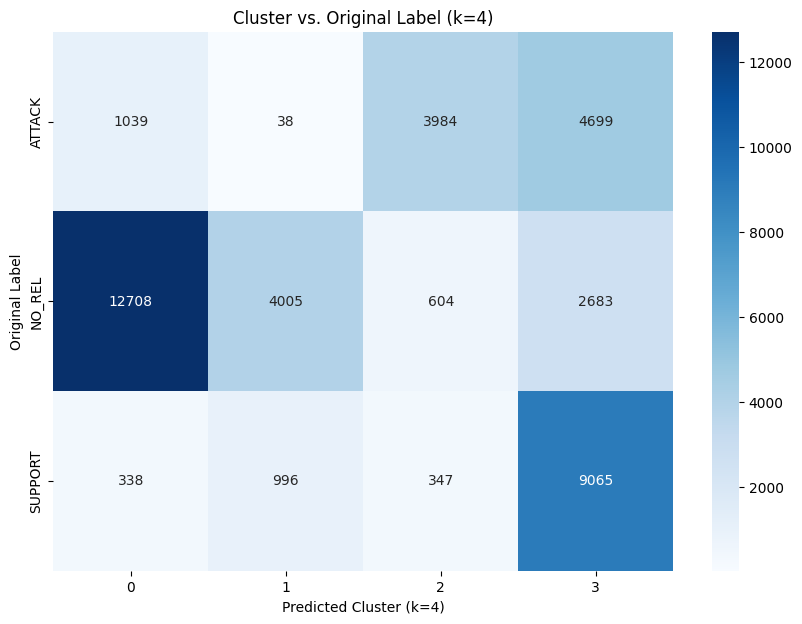

In [17]:
if df_aligned is not None:
    if 'cluster' in df_aligned.columns:
        logger.info("--- Cluster Composition Analysis ---")

        crosstab = pd.crosstab(df_aligned['label'], df_aligned['cluster'])
        print("\\nCross-tabulation (Original Label vs. Predicted Cluster):")
        print(crosstab)

        plt.figure(figsize=(10, 7)) # Adjusted size slightly
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
        # Use the n_clusters variable in the title and xlabel
        plt.title(f"Cluster vs. Original Label (k={n_clusters})")
        plt.xlabel(f"Predicted Cluster (k={n_clusters})")
        plt.ylabel("Original Label")
        plt.show()
    else:
        logger.error("K-Means clustering step did not complete. Cannot show composition.")
else:
    logger.error("Cannot analyze composition because data is not loaded.")



In [18]:
if df_aligned is not None and 'cluster' in df_aligned.columns:
    pd.set_option('display.max_colwidth', 200)

    # Display samples for each cluster found
    unique_clusters = sorted(df_aligned['cluster'].unique())
    num_clusters_found = len(unique_clusters) # Get actual number found
    logger.info(f"Found {num_clusters_found} unique cluster labels: {unique_clusters}")


    for clus_id in unique_clusters:
        print("\\n" + "="*50)
        logger.info(f"Sample Points from Cluster {clus_id}")
        print("="*50)
        cluster_data = df_aligned[df_aligned['cluster'] == clus_id]
        sample_size = min(5, len(cluster_data)) # Sample up to 5

        if sample_size > 0:
           print(cluster_data[['sent1', 'sent2', 'label']].sample(sample_size, random_state=42))
        else:
           print(f"Cluster {clus_id} has no samples.")
else:
    logger.error("Cannot inspect samples because data or cluster labels are missing.")

2025-10-29 09:23:53,789 - INFO - Found 4 unique cluster labels: [0, 1, 2, 3]
2025-10-29 09:23:53,790 - INFO - Sample Points from Cluster 0
2025-10-29 09:23:53,801 - INFO - Sample Points from Cluster 1
2025-10-29 09:23:53,809 - INFO - Sample Points from Cluster 2
2025-10-29 09:23:53,815 - INFO - Sample Points from Cluster 3


\n==================================================
                                                                                                                                                                                                         sent1  \
1019                                       Ineligibility and disqualification of officers for court-martial --(1 ) An officer is not eligible for serving on a court-martial if he is not subject to the Act .   
2656   The contention of the appellant was that the contract was not a non-transferable specific delivery contract as defined in Section 2 ( f ) of the Act and as such it was illegal and void and the arb...   
11775                                                                                                                                                                                                            
10464                                                        For the said purpose , the court has to be bea

2025-10-29 09:23:53,838 - INFO - Reducing dimensions with UMAP for visualization...
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
2025-10-29 09:24:39,220 - INFO - Plotting by K-Means Cluster (k=4)...


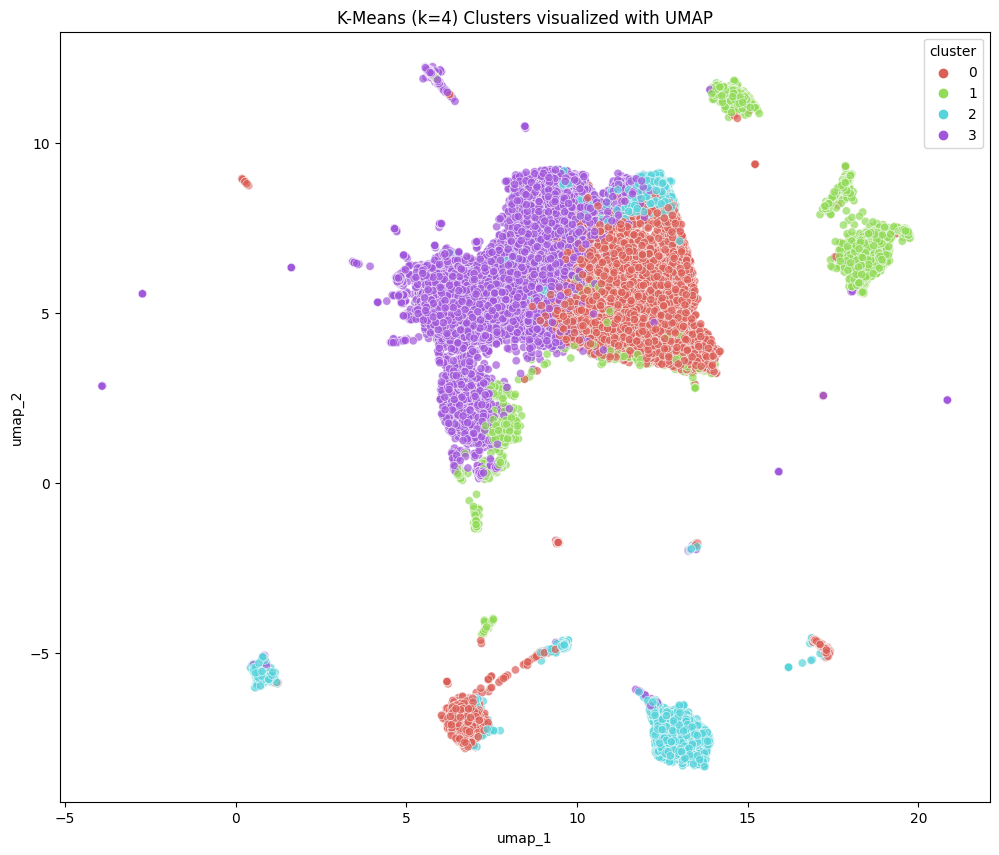

2025-10-29 09:24:40,681 - INFO - Plotting by Original Label...


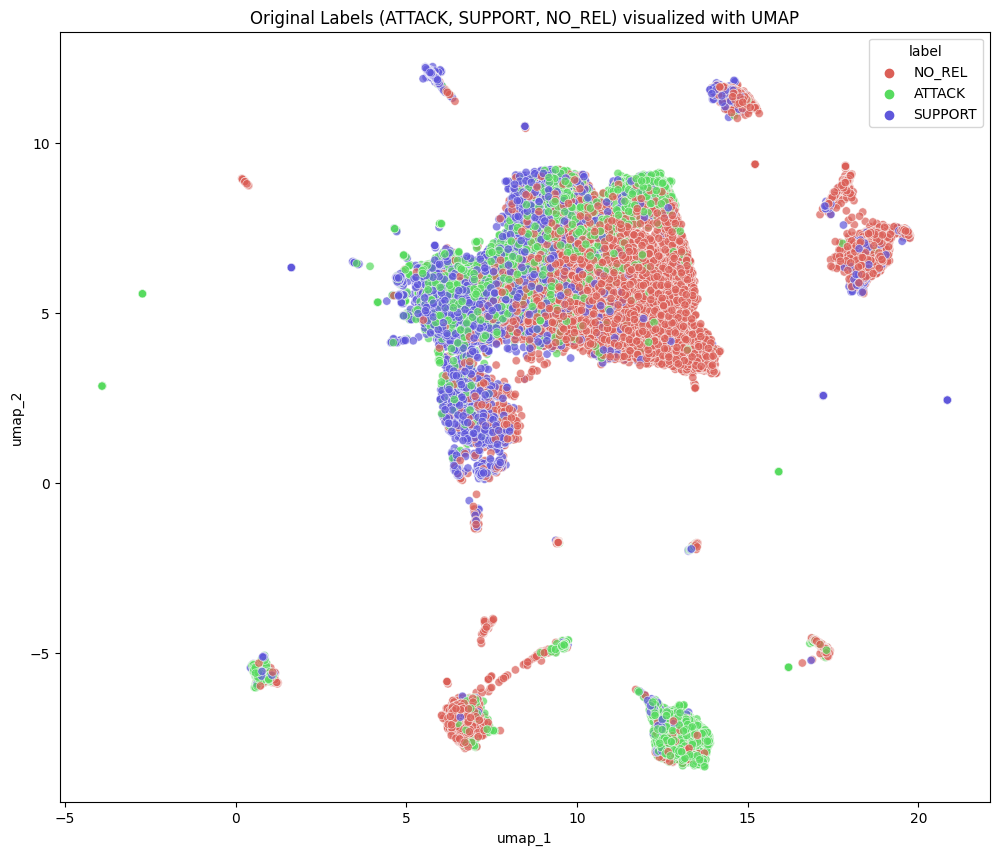

2025-10-29 09:24:42,146 - INFO - Plotting UMAP with Color=Cluster (k=4), Shape=Original Label...


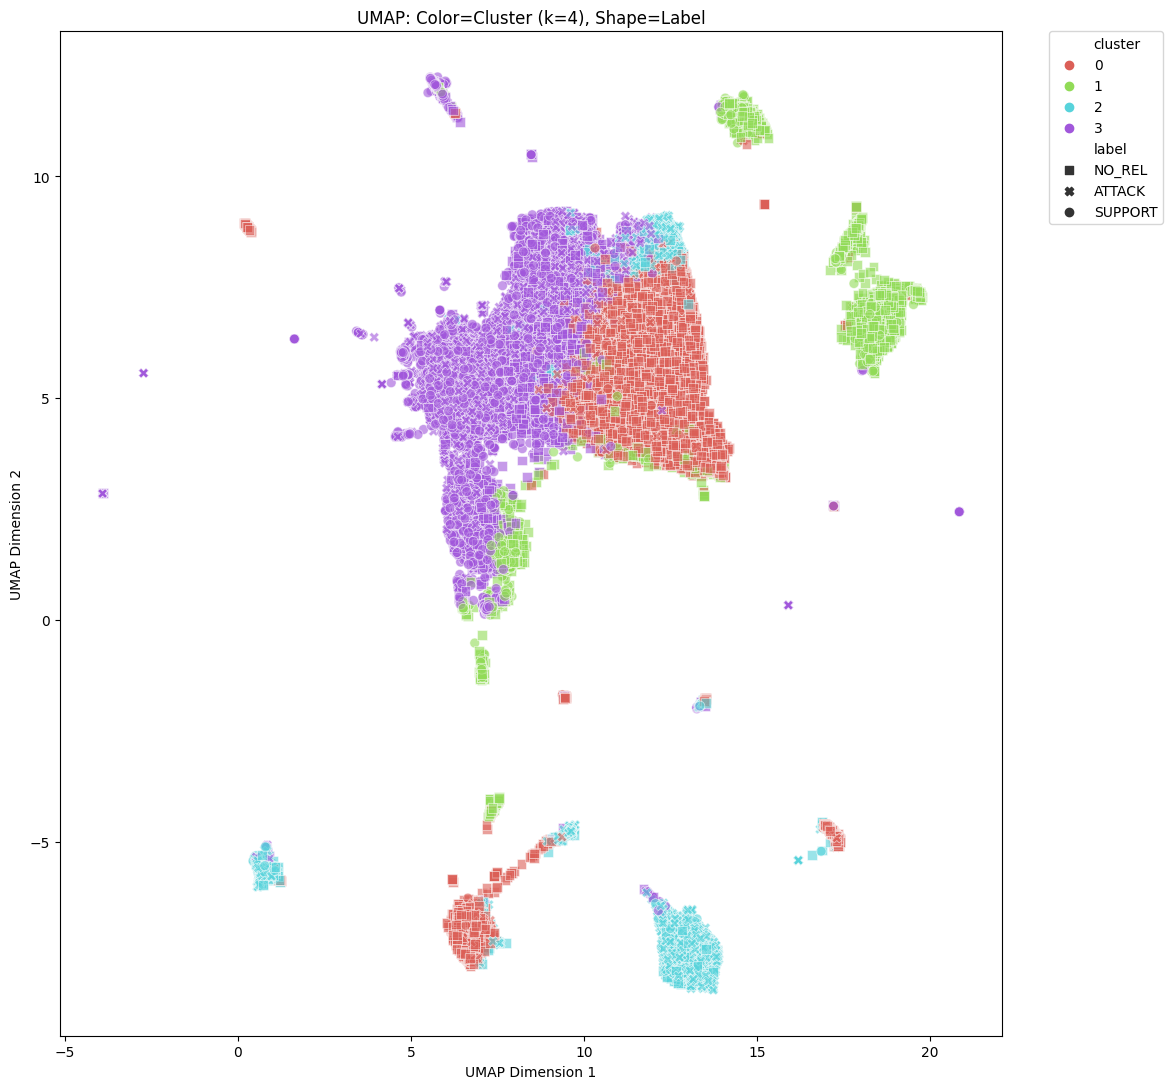

In [19]:
if df_aligned is not None and embeddings is not None and 'cluster' in df_aligned.columns:
    logger.info("Reducing dimensions with UMAP for visualization...")

    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    df_aligned['umap_1'] = embeddings_2d[:, 0]
    df_aligned['umap_2'] = embeddings_2d[:, 1]

    # --- Plot 1: Color by K-Means Cluster ---
    logger.info(f"Plotting by K-Means Cluster (k={n_clusters})...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',
        # Use a palette suitable for n_clusters
        palette=sns.color_palette('hls', n_clusters),
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title(f'K-Means (k={n_clusters}) Clusters visualized with UMAP')
    plt.show()

    # --- Plot 2: Color by Original Label ---
    logger.info("Plotting by Original Label...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='label',
        palette=sns.color_palette('hls', 3), # 3 original labels
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title('Original Labels (ATTACK, SUPPORT, NO_REL) visualized with UMAP')
    plt.show()

    # --- Plot 3 (NEW): Color by Cluster, Shape by Label ---
    logger.info(f"Plotting UMAP with Color=Cluster (k={n_clusters}), Shape=Original Label...")
    plt.figure(figsize=(14, 11))

    scatter = sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',      # Color by K-Means cluster
        style='label',      # Shape by original label
        palette=sns.color_palette('hls', n_clusters), # Use n_clusters colors
        markers={'ATTACK': 'X', 'SUPPORT': 'o', 'NO_REL': 's'}, # Assign markers
        data=df_aligned,
        alpha=0.6,
        s=50 # Point size
    )

    plt.title(f'UMAP: Color=Cluster (k={n_clusters}), Shape=Label')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    logger.error("Cannot create UMAP plots because data, embeddings, or cluster labels are missing.")